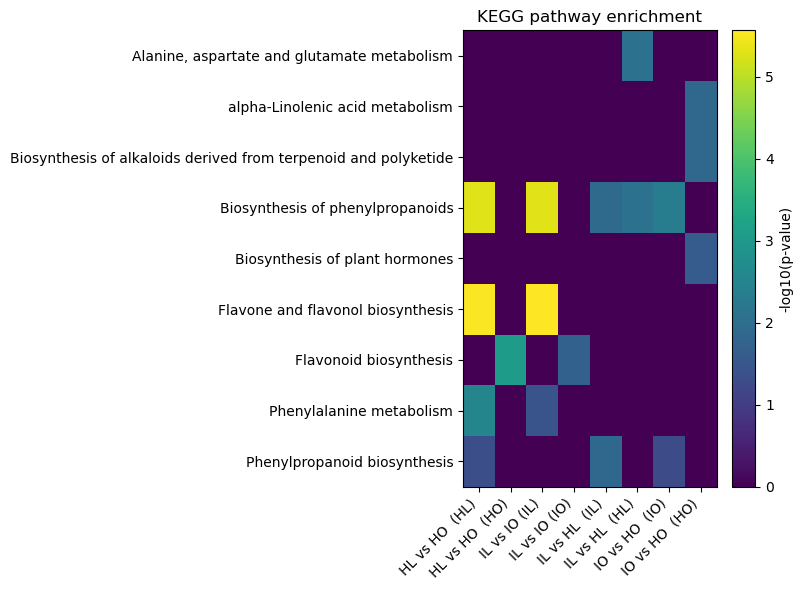

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Charger le fichier (remplace par ton chemin)
df = pd.read_excel("C:/Users/tamer/Documents/PhD/ML/KEGG_enrichment/bubble_plot.xlsx", sheet_name = 'log')

# Définir les pathways comme index
df = df.set_index("Map")

# Plot
plt.figure(figsize=(8,6))

plt.imshow(df, aspect="auto")

plt.xticks(range(len(df.columns)), df.columns, rotation=45, ha="right")
plt.yticks(range(len(df.index)), df.index)

cbar = plt.colorbar()
cbar.set_label("-log10(p-value)")

plt.title("KEGG pathway enrichment")

plt.tight_layout()
plt.show()

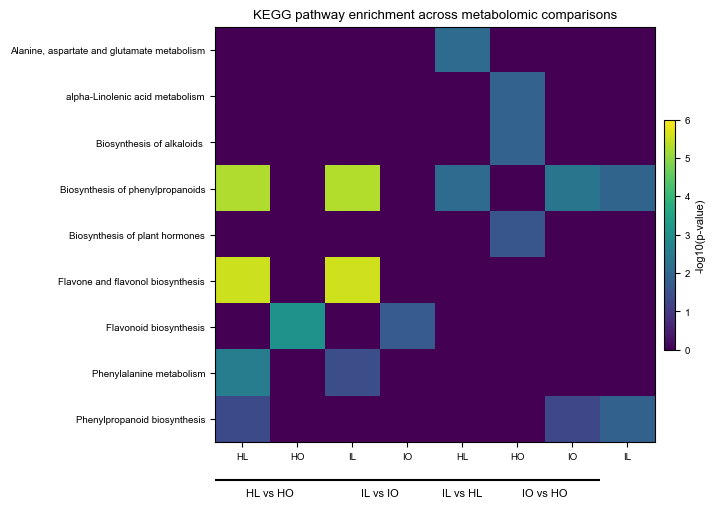

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import matplotlib as mpl
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['pdf.use14corefonts'] = False
# -------------------------
# LOAD DATA
# -------------------------
df = pd.read_excel(
    "C:/Users/tamer/Documents/PhD/ML/KEGG_enrichment/bubble_plot.xlsx",
    sheet_name = 'v2'
)

# -------------------------
# ORDER (IMPORTANT)
# -------------------------
comparison_order = ["HL vs HO", "IL vs IO", "IL vs HL", "IO vs HO"]

df["Comparison"] = pd.Categorical(df["Comparison"],
                                  categories=comparison_order,
                                  ordered=True)

df = df.sort_values(["Comparison", "Class"]).reset_index(drop=True)

# -------------------------
# DATA MATRIX
# -------------------------
meta_cols = ["Comparison", "Class"]
value_cols = [c for c in df.columns if c not in meta_cols]
data = df[value_cols].values

# -------------------------
# STYLE
# -------------------------
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7
})

# -------------------------
# FIGURE (double column)
# -------------------------
fig, ax = plt.subplots(figsize=(7.2, 5))

im = ax.imshow(data.T, aspect="auto", vmin=0, vmax=6)

# -------------------------
# Y axis
# -------------------------
ax.set_yticks(range(len(value_cols)))
ax.set_yticklabels(value_cols)

# -------------------------
# X axis = CLASS (level 1)
# -------------------------
ax.set_xticks(range(len(df)))
ax.set_xticklabels(df["Class"], rotation=0)

# -------------------------
# SECOND LEVEL (comparison BELOW)
# -------------------------
for comp in comparison_order:
    idx = np.where(df["Comparison"] == comp)[0]
    if len(idx) == 0:
        continue

    center = np.mean(idx)

    # label comparaison (plus bas)
    ax.text(center,
            -0.11,
            comp,
            ha="center",
            va="top",
            transform=ax.get_xaxis_transform(),
            fontsize=8)

    # barre de groupement
    ax.hlines(
        y=-0.09,
        xmin=idx[0] - 0.5,
        xmax=idx[-1] + 0.5,
        transform=ax.get_xaxis_transform(),
        color="black",
        linewidth=1.5,
        clip_on=False
    )

# -------------------------
# COLORBAR
# -------------------------
cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("-log10(p-value)")

# -------------------------
# TITLE
# -------------------------
ax.set_title("KEGG pathway enrichment across metabolomic comparisons", pad=6)

# -------------------------
# LAYOUT (CRITICAL)
# -------------------------
plt.subplots_adjust(bottom=0.28)

plt.tight_layout()

# -------------------------
# SAVE
# -------------------------
plt.savefig(
    "C:/Users/tamer/Documents/PhD/ML/KEGG_enrichment/heatmap_final_corrected.tif",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "C:/Users/tamer/Documents/PhD/ML/KEGG_enrichment/heatmap_final_corrected.pdf",
    bbox_inches="tight"
)

plt.show()